# Classification par Variété : 

In [2]:
import os
import shutil
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter
import random
import numpy as np
from collections import defaultdict
from tqdm import tqdm
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch import nn, optim
from sklearn.metrics import classification_report, confusion_matrix
import torchviz
import time


In [3]:
# ===================================================================
def print_tree(dir_path, indent=""):
    for item in sorted(os.listdir(dir_path)):
        path = os.path.join(dir_path, item)
        if os.path.isdir(path):
            print(f"{indent}📁 {item}")
            print_tree(path, indent + "    ")

# ===================================================================

In [4]:
# data paths : ===================================================================
DATASET_DIR =  "../data/dataset_classification/dataset_variete/"

os.makedirs(DATASET_DIR, exist_ok=True)
# ===================================================================
EXTENSIONS = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG")
# ===================================================================

In [5]:
import torch

# Définir le device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Le modèle tournera sur : {device}")


Le modèle tournera sur : cuda


In [6]:
print_tree(DATASET_DIR)

📁 Boufagous
📁 Boumajhoul
📁 bouisthami
📁 kholt


- Charger les images du dataset et vérifier leurs extensions (jpeg, jpg, bmp, png). Supprimer celles qui ne correspondent pas.

In [7]:

def load_dataset_images(dataset_dir, extensions):
    """
    Parcourt un répertoire de dataset pour extraire les chemins d'images et leurs labels.
    
    Args:
        dataset_dir (str): Le chemin vers le dossier principal du dataset.
        extensions (tuple): Un tuple des extensions valides en minuscules (ex: ('.png', '.jpg', '.jpeg')).
        
    Returns:
        tuple: (image_paths, labels, total_images, problem_files)
    """
    image_paths = []
    labels = []
    
    problem_files = 0
    total_images = 0
    
    for class_name in os.listdir(dataset_dir):
        class_path = os.path.join(dataset_dir, class_name)
    
        if not os.path.isdir(class_path):
            continue
    
        for file_name in os.listdir(class_path):
            total_images += 1
            file_path = os.path.join(class_path, file_name)
    
            if not file_name.lower().endswith(extensions):
                problem_files += 1
                continue
    
            try:
                # Vérifie que l'image peut être chargée correctement
                img = cv2.imread(file_path)
                if img is None:
                    problem_files += 1
                    continue
    
                image_paths.append(file_path)
                labels.append(class_name)
    
            except Exception as e:
                problem_files += 1
                print(f"Erreur chargement: {file_path} -> {e}")

    return image_paths, labels, total_images, problem_files


In [8]:


# Appeler la fonction et récupérer les résultats :
image_paths, labels, total_images, problem_files = load_dataset_images(DATASET_DIR, EXTENSIONS)

print(f"Images valides récupérées : {len(image_paths)}")
print(f"Nombre d'images avec des problèmes : {problem_files}")
print(f"Images totales trouvées : {total_images}")


Images valides récupérées : 0
Nombre d'images avec des problèmes : 0
Images totales trouvées : 0


2️⃣ Exploration et visualisation du dataset

- Explorer les classes du dataset (les noms des dossiers représentent les classes).

In [9]:
# Explorer les classes
classes = [d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))]

print(f"Les classes sont : {classes}")

Les classes sont : ['Boufagous', 'bouisthami', 'Boumajhoul', 'kholt']


- Montrez un nombre d’échantillons dans chaque classe par countplot.

In [10]:



def distribution_classes(labels):
    """
    Affiche la distribution des classes (graphique + nombres).
    """

    plt.figure(figsize=(8, 5))

    sns.countplot(
        x=labels,
        order=pd.Series(labels).value_counts().index,
        palette="viridis"
    )

    plt.title("Nombre d'échantillons par classe")
    plt.xlabel("Classe")
    plt.ylabel("Nombre d'images")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    # compter les images par classe
    class_counts = Counter(labels)

    print("\n📊 Nombre d'images par classe :\n")

    for class_name, count in sorted(class_counts.items()):
        print(f"Classe '{class_name}' : {count} images")

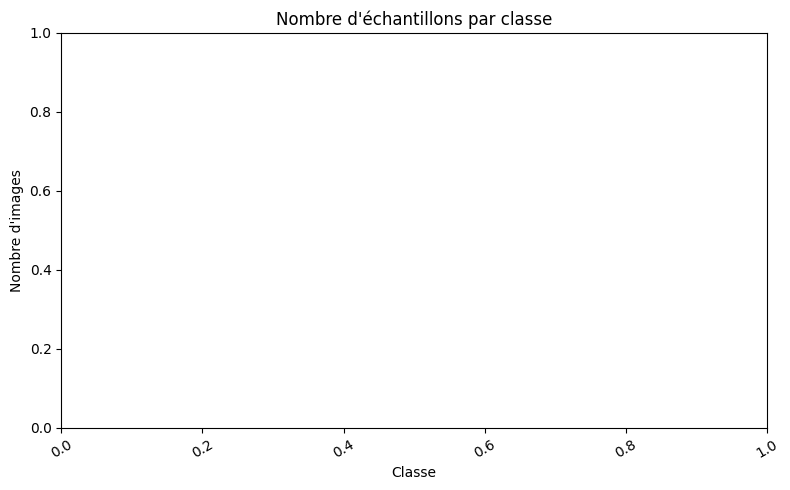


📊 Nombre d'images par classe :



In [11]:
distribution_classes(labels)

Montrer un échantillon d’images pour chaque classe.

In [12]:


def show_random_images(dataset_dir, extensions=(".jpg", ".jpeg", ".png"), n_images=4):
    """
    Affiche n_images aléatoires par classe depuis un dataset organisé par :
    dataset_dir / classe / (S1..S4) / images
    """

    classes = [
        d for d in os.listdir(dataset_dir)
        if os.path.isdir(os.path.join(dataset_dir, d))
    ]

    plt.figure(figsize=(4 * n_images, 4 * len(classes)))
    plot_index = 1

    for class_name in classes:
        class_path = os.path.join(dataset_dir, class_name)

        # récupérer toutes les images dans S1..S4
        images = [
            str(p) for p in Path(class_path).rglob("*")
            if p.is_file() and p.suffix.lower() in extensions
        ]

        if not images:
            continue

        selected_images = random.sample(images, min(n_images, len(images)))

        for img_path in selected_images:
            image = cv2.imread(img_path)

            if image is None:
                continue

            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            plt.subplot(len(classes), n_images, plot_index)
            plt.imshow(image_rgb)
            plt.title(class_name, fontsize=10)
            plt.axis("off")

            plot_index += 1

    plt.tight_layout()
    plt.show()

In [13]:
show_random_images(DATASET_DIR, EXTENSIONS, n_images=4)

<Figure size 1600x1600 with 0 Axes>

* Analyses des dimensions des images des classes :

In [14]:



def analyze_image_dimensions(dataset_path, classes, extensions=(".png", ".jpg", ".jpeg"), sample_size=50):
    """
    Analyse les dimensions des images par classe.

    dataset_path : chemin du dataset
    classes      : liste des classes
    extensions   : extensions d'images acceptées
    sample_size  : nombre d'images analysées par classe
    """

    dimensions = defaultdict(list)

    for class_name in classes:

        class_path = os.path.join(dataset_path, class_name)

        if not os.path.exists(class_path):
            print(f"⚠️ Classe introuvable : {class_name}")
            continue

        images = [
            f for f in os.listdir(class_path)
            if f.lower().endswith(extensions)
        ]

        print(f"\n🔎 Analyse de la classe '{class_name}' ({len(images)} images)")

        for img_name in tqdm(images[:sample_size]):

            img_path = os.path.join(class_path, img_name)

            img = cv2.imread(img_path)

            if img is not None:
                h, w = img.shape[:2]
                dimensions[class_name].append((h, w))

        if dimensions[class_name]:

            heights = [d[0] for d in dimensions[class_name]]
            widths = [d[1] for d in dimensions[class_name]]

            print(f"  Hauteur : min={min(heights)}, max={max(heights)}, moyenne={np.mean(heights):.0f}")
            print(f"  Largeur : min={min(widths)}, max={max(widths)}, moyenne={np.mean(widths):.0f}")

    return dimensions

In [15]:

dimensions = analyze_image_dimensions(
    DATASET_DIR,
    classes,
    sample_size=50
)


🔎 Analyse de la classe 'Boufagous' (0 images)


0it [00:00, ?it/s]



🔎 Analyse de la classe 'bouisthami' (0 images)


0it [00:00, ?it/s]



🔎 Analyse de la classe 'Boumajhoul' (0 images)


0it [00:00, ?it/s]



🔎 Analyse de la classe 'kholt' (0 images)


0it [00:00, ?it/s]


3️⃣ Division du dataset

In [16]:
import splitfolders


DATASET_DIR_SPLITED = "../data/dataset_classification/data_splited_v"

splitfolders.ratio(
    DATASET_DIR,
    output=DATASET_DIR_SPLITED,
    seed=42,
    ratio=(0.7, 0.2, 0.1),
    move=True
)

Copying files: 0 files [00:00, ? files/s]


In [17]:


def compute_dataset_stats(dataset_dir, extensions=(".jpg", ".jpeg", ".png")):
    """
    Calcule le nombre d'images par classe pour chaque split (train, val, test).
    Retourne un DataFrame pandas.
    """

    stats = []

    for split in ["train", "val", "test"]:

        split_path = os.path.join(dataset_dir, split)

        if not os.path.exists(split_path):
            continue

        for class_name in os.listdir(split_path):

            class_path = os.path.join(split_path, class_name)

            if not os.path.isdir(class_path):
                continue

            n_images = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith(extensions)
            ])

            stats.append({
                "Split": split,
                "Classe": class_name,
                "Nombre_images": n_images
            })

    df_stats = pd.DataFrame(stats)

    return df_stats

In [18]:
df_stats = compute_dataset_stats(DATASET_DIR_SPLITED)

df_stats

,Split,Classe,Nombre_images
0,train,Boufagous,3027
1,train,bouisthami,251
2,train,Boumajhoul,1851
3,train,kholt,1232
4,val,Boufagous,865
5,val,bouisthami,72
6,val,Boumajhoul,529
7,val,kholt,352
8,test,Boufagous,433
9,test,bouisthami,37


In [19]:



def analyze_split_distribution(df_stats):
    """
    Analyse la distribution des images par split et par classe.
    Affiche :
    - total d'images par split
    - barplot de distribution
    - tableau résumé
    """

    # total par split
    print("📊 Nombre total d’images par split :\n")
    print(df_stats.groupby("Split")["Nombre_images"].sum())

    # graphique
    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=df_stats,
        x="Classe",
        y="Nombre_images",
        hue="Split"
    )

    plt.title("Distribution des images par classe et par split")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # tableau résumé
    summary = df_stats.pivot(
        index="Classe",
        columns="Split",
        values="Nombre_images"
    )

    summary["Total"] = summary.sum(axis=1)

    print("\n📋 Tableau résumé :\n")
    print(summary)

    return summary

📊 Nombre total d’images par split :

Split
test      912
train    6361
val      1818
Name: Nombre_images, dtype: int64


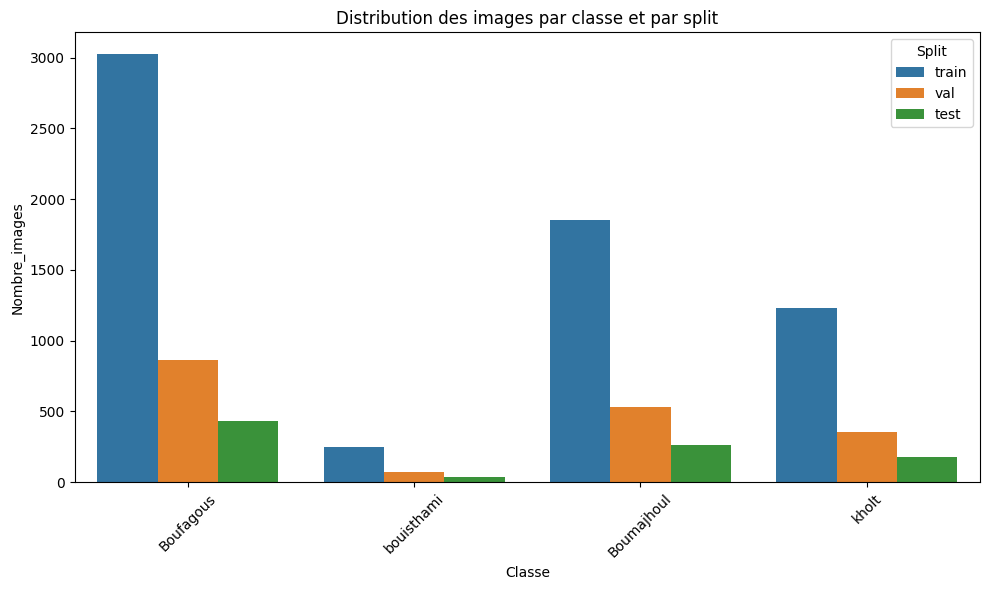


📋 Tableau résumé :

Split       test  train  val  Total
Classe                             
Boufagous    433   3027  865   4325
Boumajhoul   265   1851  529   2645
bouisthami    37    251   72    360
kholt        177   1232  352   1761


In [20]:
summary = analyze_split_distribution(df_stats)

4️⃣ équilibrer la data :

* Définir les transformations

In [21]:
# from torchvision import transforms

# train_transforms = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomRotation(20),
#     transforms.GaussianBlur(3),
#     transforms.ToTensor(),
#     transforms.Normalize([0.485, 0.456, 0.406],
#                          [0.229, 0.224, 0.225]),
# ])

# val_test_transforms = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize([0.485, 0.456, 0.406],
#                          [0.229, 0.224, 0.225]),
# ])



from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),   # 🔹 resize uniquement
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),   # 🔹 pareil pour val/test
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

* Charger le dataset

In [22]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

train_dataset = ImageFolder(
    "../data/dataset_classification/data_splited_v/train",
    transform=train_transforms
)

val_dataset = ImageFolder(
    "../data/dataset_classification/data_splited_v/val",
    transform=val_test_transforms
)

test_dataset = ImageFolder(
    "../data/dataset_classification/data_splited_v/test",
    transform=val_test_transforms
)

In [23]:
img, label = train_dataset[0]
print(img.shape)

torch.Size([3, 224, 224])


* afficher un batch redimensionné

In [24]:
def show_resized_samples(dataset, n_images=8):
    import torch
    import matplotlib.pyplot as plt
    import numpy as np
    import random

    # 🔹 Fonction denormalize
    def denormalize(img):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        return img * std + mean

    indices = random.sample(range(len(dataset)), min(n_images, len(dataset)))

    rows = int(np.ceil(n_images / 4))
    cols = min(n_images, 4)

    plt.figure(figsize=(12, 3 * rows))

    for i, idx in enumerate(indices):

        img, label = dataset[idx]

        img = denormalize(img)
        img = img.permute(1, 2, 0).cpu().numpy()

        plt.subplot(rows, cols, i + 1)
        plt.imshow(np.clip(img, 0, 1))
        plt.title(dataset.classes[label])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [25]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)


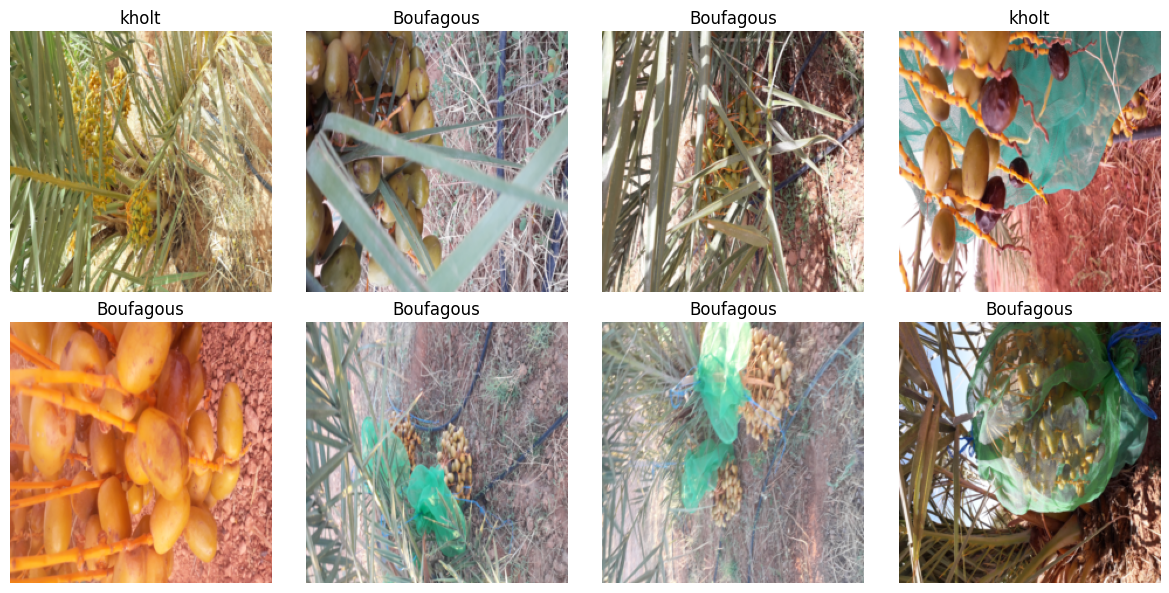

In [26]:
show_resized_samples(train_dataset, n_images=8)

* visualizer la distribution des classe dans les parites : train, test, val

In [27]:
def visualisation(data, part="data"):
    import matplotlib.pyplot as plt
    import seaborn as sns
    from collections import Counter
    import pandas as pd

    targets = data.targets

    class_counts = Counter(targets)

    class_names = data.classes

    data = []
    for class_index, count in class_counts.items():
        data.append({
            "Classe": class_names[class_index],
            "Nombre_images": count
        })

    df = pd.DataFrame(data).sort_values(by="Nombre_images", ascending=False)

    print("📊 Nombre d'images par classe (Train) :\n")
    for _, row in df.iterrows():
        print(f"{row['Classe']} : {row['Nombre_images']} images")

    # Graphique
    plt.figure(figsize=(8,5))
    sns.barplot(
        data=df,
        x="Classe",
        y="Nombre_images",
        palette='viridis'
    )
    plt.title("Distribution des classes - Train Dataset")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

📊 Nombre d'images par classe (Train) :

Boufagous : 3027 images
Boumajhoul : 1851 images
kholt : 1232 images
bouisthami : 251 images


C:\Users\ramas\AppData\Local\Temp\ipykernel_19708\586353928.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


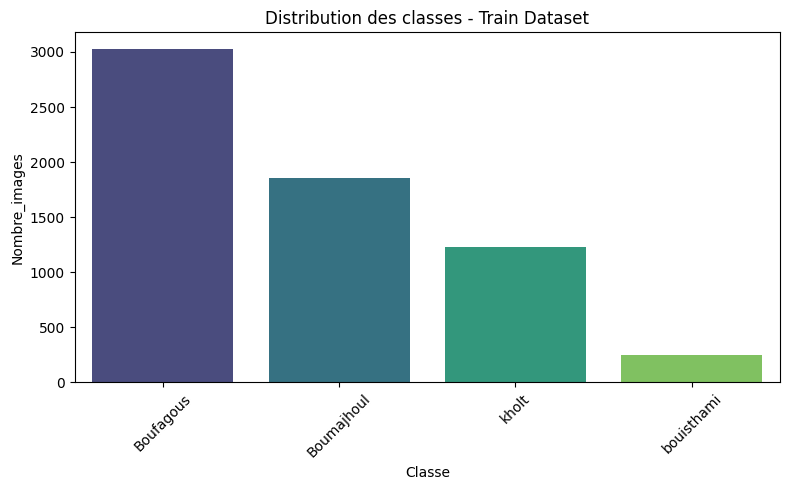

📊 Nombre d'images par classe (Train) :

Boufagous : 433 images
Boumajhoul : 265 images
kholt : 177 images
bouisthami : 37 images


C:\Users\ramas\AppData\Local\Temp\ipykernel_19708\586353928.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


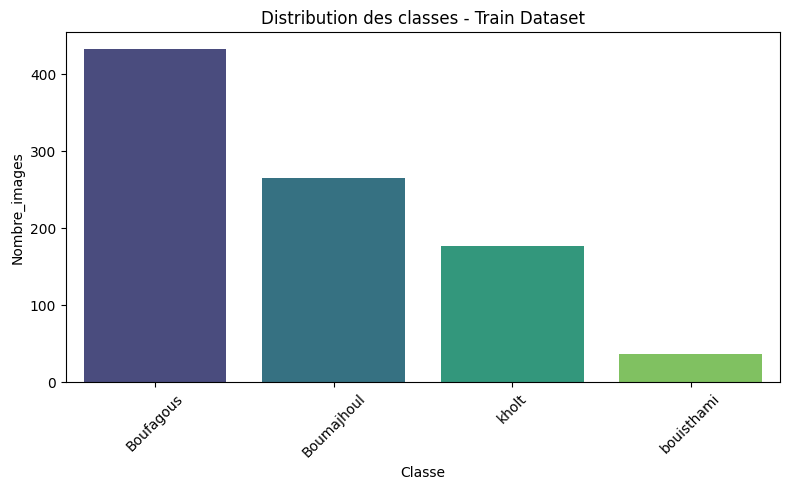

📊 Nombre d'images par classe (Train) :

Boufagous : 865 images
Boumajhoul : 529 images
kholt : 352 images
bouisthami : 72 images


C:\Users\ramas\AppData\Local\Temp\ipykernel_19708\586353928.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


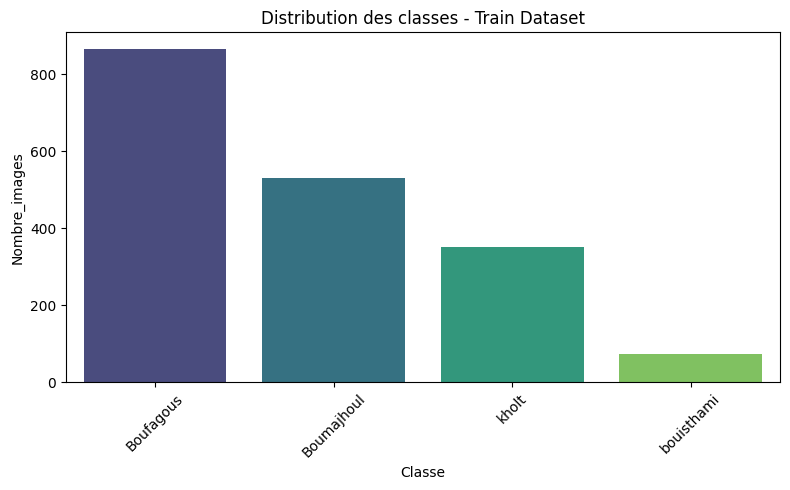

In [28]:
visualisation(train_dataset, part="train")
visualisation(test_dataset, part="test")
visualisation(val_dataset, part="val")

* Equilibrer les classes : 

In [29]:
from torchvision import transforms

augmentation_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(25),
    transforms.RandomResizedCrop(224, scale=(0.8,1.0)),
    transforms.GaussianBlur(3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [30]:
import numpy as np
from torch.utils.data import SubsetRandomSampler

def create_balanced_sampler(train_dataset, target_per_class=1500):

    targets = np.array(train_dataset.targets)
    classes = np.unique(targets)

    balanced_indices = []

    for cls in classes:
        cls_indices = np.where(targets == cls)[0]

        if len(cls_indices) > target_per_class:
            # 🔻 Under-sampling
            sampled = np.random.choice(
                cls_indices,
                target_per_class,
                replace=False
            )

        else:
            # 🔺 Over-sampling (avec augmentation)
            sampled = np.random.choice(
                cls_indices,
                target_per_class,
                replace=True
            )

            # activer les transforms d'augmentation
            train_dataset.transform = augmentation_transforms

        balanced_indices.extend(sampled)

    np.random.shuffle(balanced_indices)

    sampler = SubsetRandomSampler(balanced_indices)

    return sampler

In [31]:
sampler = create_balanced_sampler(train_dataset, target_per_class=1500)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,
    num_workers=2
)

C:\Users\ramas\AppData\Local\Temp\ipykernel_19708\1174884035.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=values, palette="viridis")


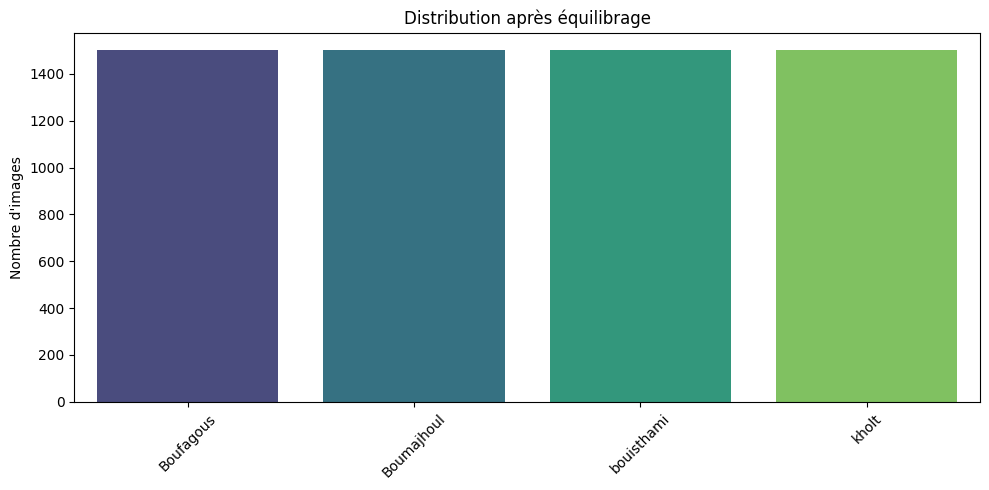

In [32]:
def plot_loader_distribution(loader, dataset):

    import seaborn as sns
    import matplotlib.pyplot as plt
    from collections import Counter

    labels = []

    for _, y in loader:
        labels.extend(y.numpy())

    counts = Counter(labels)

    classes = dataset.classes
    values = [counts[i] for i in range(len(classes))]

    plt.figure(figsize=(10,5))
    sns.barplot(x=classes, y=values, palette="viridis")

    plt.xticks(rotation=45)
    plt.title("Distribution après équilibrage")
    plt.ylabel("Nombre d'images")
    plt.tight_layout()
    plt.show()


plot_loader_distribution(train_loader, train_dataset)

In [33]:
# train_loader = DataLoader(
#     train_dataset,
#     batch_size=32,
#     sampler=sampler
# )

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [34]:
from collections import Counter

balanced_labels = []

for _, labels in train_loader:
    balanced_labels.extend(labels.numpy())

print("Distribution après sampling :", Counter(balanced_labels))

Distribution après sampling : Counter({np.int64(0): 1500, np.int64(3): 1500, np.int64(2): 1500, np.int64(1): 1500})



 Train  : 


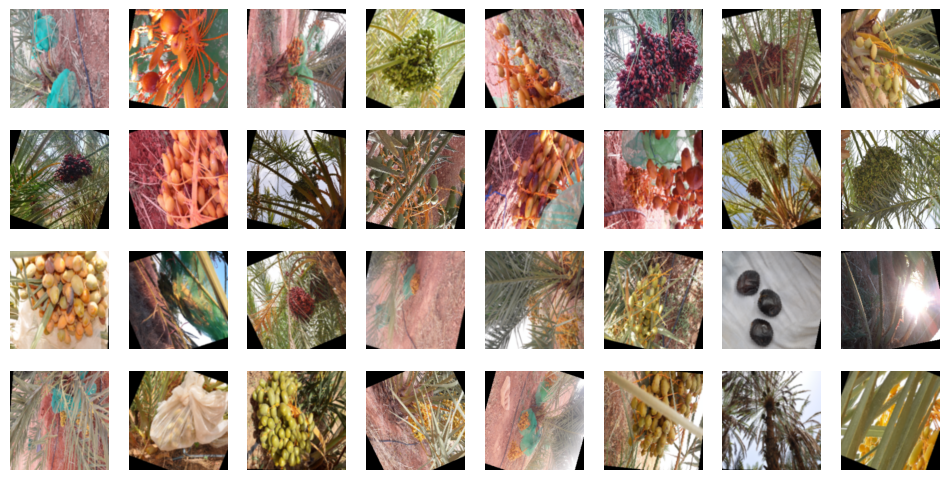

In [35]:
def img_show_batch(dataloder, title):
    images, labels = next(iter(dataloder))
    fig, axes = plt.subplots(4, 8, figsize=(12, 6))
    for i, ax in enumerate(axes.flat):
        if i >= len(images):
            break
        img = images[i].permute(1, 2, 0).numpy()
        img = (img * [0.229, 0.224, 0.225]) +  [0.485, 0.456, 0.406]
        img = img.clip(0, 1)
        ax.imshow(img)
        ax.axis('off')
    print("\n",title, " : ")
    plt.show()

img_show_batch(train_loader, title="Train")

***

loader data pour l'entrainement de model :

In [36]:
!pip install torchviz


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
model = models.googlenet(pretrained=True)

PATH_ANALYSE = "../analyse_configuration/variete_analyse"


c:\Users\ramas\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ramas\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


* Vérification de modele googlenet :

In [38]:
# Avec Modifier le FC

x = torch.randn(1, 3, 224, 224)
y = model(x)
torchviz.make_dot(y, params=dict(model.named_parameters())).render(f"{PATH_ANALYSE}/googlenet_avant", format="png")

'..\\analyse_configuration\\variete_analyse\\googlenet_avant.png'

In [39]:
model.fc

Linear(in_features=1024, out_features=1000, bias=True)

* Remplacer la partie fully connected (FC) par un réseau séquentiel adapté à la tâche

In [40]:
import torch.nn as nn

nbr_classes = 4

model.fc = nn.Sequential(
    nn.Linear(1024, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.5),

    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(128, nbr_classes)
)

In [41]:
model.fc


Sequential(
  (0): Linear(in_features=1024, out_features=512, bias=True)
  (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=512, out_features=128, bias=True)
  (5): ReLU()
  (6): Dropout(p=0.3, inplace=False)
  (7): Linear(in_features=128, out_features=4, bias=True)
)

In [42]:
# Après la modification de FC

x = torch.randn(4, 3, 224, 224)
y = model(x)
torchviz.make_dot(y, params=dict(model.named_parameters())).render(f"{PATH_ANALYSE}/googlenet_apres", format="png")

'..\\analyse_configuration\\variete_analyse\\googlenet_apres.png'

🟡🟡 Entrainement de modèle :

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
# model = model.to(device)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [44]:
model.fc.parameters()

<generator object Module.parameters at 0x000002A2F54220A0>

In [45]:
learning_rate = 0.0001
loss_funct = nn.CrossEntropyLoss()
optimiseur = optim.Adam(model.fc.parameters(), lr=learning_rate)

* Entraîner le modèle

In [46]:
train_loss = []
train_accuracy = []
val_accuracy = []

In [ ]:


def train_model(model, train_loader, val_loader, loss_funct, optimiseur, device, nbr_epochs=10):
    """
    Entraîne un modèle PyTorch avec suivi de l'accuracy et du loss.

    Args:
        model: le modèle PyTorch
        train_loader: DataLoader du train set
        val_loader: DataLoader du validation set
        loss_funct: fonction de perte (ex: nn.CrossEntropyLoss)
        optimiseur: optimiseur (ex: torch.optim.Adam)
        device: "cuda" ou "cpu"
        nbr_epochs: nombre d'epochs
    Returns:
        dict avec : train_loss, train_accuracy, val_accuracy, training_time
    """

    train_loss = []
    train_accuracy = []
    val_accuracy = []

    print(f"▶️ Début de l'entraînement sur {device}...")
    start_time = time.time()

    for epoch in range(nbr_epochs):
        start_time_epoch = time.time()
        print(f"\n🔹 Epoch [{epoch+1}/{nbr_epochs}]")

        # ==========================
        # Phase train
        # ==========================
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimiseur.zero_grad()
            outputs = model(images)
            loss = loss_funct(outputs, labels)
            loss.backward()
            optimiseur.step()

            running_loss += loss.item() * images.size(0)  # accumulate weighted by batch size
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        epoch_loss = running_loss / total
        train_acc = correct / total

        # ==========================
        # Phase validation
        # ==========================
        model.eval()
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total_val += labels.size(0)
                correct_val += predicted.eq(labels).sum().item()

        val_acc = correct_val / total_val

        # Sauvegarde des métriques
        train_loss.append(epoch_loss)
        train_accuracy.append(train_acc)
        val_accuracy.append(val_acc)

        print(f"    Loss: {epoch_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
        end_time_epoch = time.time()
        training_time_epoch = end_time_epoch - start_time_epoch
        print(f"\n      🕐 Epoch {[{epoch+1}/{nbr_epochs}]} terminé ! Temps Epoch : {training_time_epoch/60:.2f} minutes")

    end_time = time.time()
    training_time = end_time - start_time
    print(f"\n✅ Entraînement terminé ! Temps total : {training_time/60:.2f} minutes")

    return {
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy,
        "training_time": training_time
    }

In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
nbr_epochs = 20

model.to(device)

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_funct=loss_funct,
    optimiseur=optimiseur,
    device=device,
    nbr_epochs=nbr_epochs
)

▶️ Début de l'entraînement sur cuda...

🔹 Epoch [1/20]
    Loss: 1.1518 | Train Acc: 0.4885 | Val Acc: 0.5088

🔹 Epoch [2/20]
    Loss: 0.8843 | Train Acc: 0.6117 | Val Acc: 0.5297

🔹 Epoch [3/20]
    Loss: 0.8094 | Train Acc: 0.6482 | Val Acc: 0.5666

🔹 Epoch [4/20]
    Loss: 0.7663 | Train Acc: 0.6717 | Val Acc: 0.5957

🔹 Epoch [5/20]
    Loss: 0.7406 | Train Acc: 0.6793 | Val Acc: 0.5990

🔹 Epoch [6/20]
    Loss: 0.7236 | Train Acc: 0.6928 | Val Acc: 0.6166

🔹 Epoch [7/20]
    Loss: 0.7060 | Train Acc: 0.7028 | Val Acc: 0.6425

🔹 Epoch [8/20]
    Loss: 0.6946 | Train Acc: 0.7057 | Val Acc: 0.6535

🔹 Epoch [9/20]
    Loss: 0.6904 | Train Acc: 0.7153 | Val Acc: 0.6551

🔹 Epoch [10/20]
    Loss: 0.6636 | Train Acc: 0.7202 | Val Acc: 0.6502

🔹 Epoch [11/20]
    Loss: 0.6645 | Train Acc: 0.7232 | Val Acc: 0.6568

🔹 Epoch [12/20]
    Loss: 0.6520 | Train Acc: 0.7233 | Val Acc: 0.6843

🔹 Epoch [13/20]
    Loss: 0.6551 | Train Acc: 0.7230 | Val Acc: 0.6683

🔹 Epoch [14/20]
    Loss: 0.6354 

* Evolution du loss et Accuracy pendant l'entraînement

In [49]:


def plot_training_history(history, nbr_epochs):
    """
    Affiche les courbes d'entraînement :
    - Training Loss
    - Training Accuracy
    - Validation Accuracy
    """

    train_loss = history['train_loss']
    train_accuracy = history['train_accuracy']
    val_accuracy = history['val_accuracy']

    epochs = list(range(1, nbr_epochs + 1))

    # 🔹 Courbe du Loss
    plt.figure(figsize=(8,5))
    plt.plot(epochs, train_loss, marker='o', label='Training Loss')
    plt.title("Évolution du Loss pendant l'entraînement")
    plt.xlabel("Époques")
    plt.ylabel("Loss")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 🔹 Courbe de l'Accuracy
    plt.figure(figsize=(8,5))
    plt.plot(epochs, train_accuracy, marker='o', label='Training Accuracy')
    plt.plot(epochs, val_accuracy, marker='s', label='Validation Accuracy')
    plt.title("Évolution de l'Accuracy pendant l'entraînement")
    plt.xlabel("Époques")
    plt.ylabel("Accuracy (%)")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

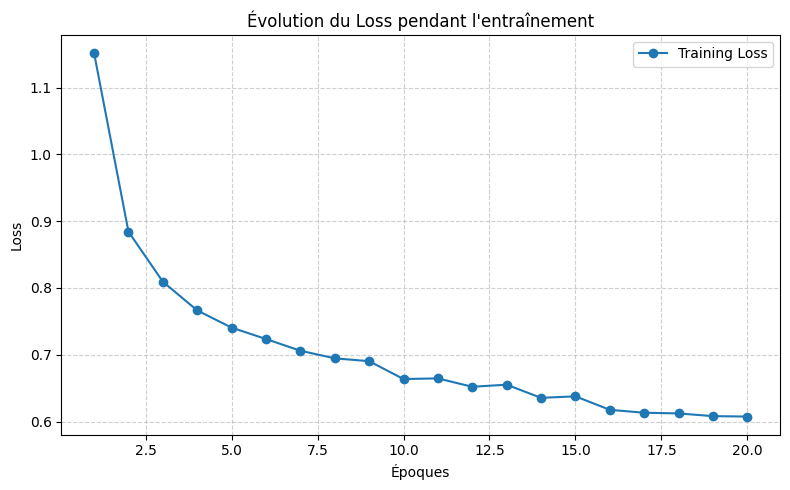

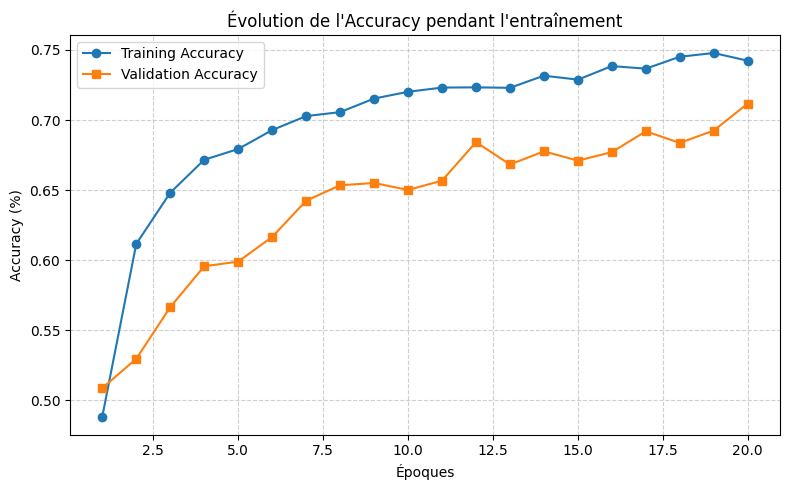

In [50]:
plot_training_history(history, nbr_epochs)

* rapport de classification :

In [51]:


def evaluate_model(model, data_loader, loss_function, device):
    """
    Évalue un modèle PyTorch sur un DataLoader
    Retourne :
        - loss moyen
        - accuracy
        - labels réels
        - prédictions
    """

    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():

        for inputs, labels in data_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            loss = loss_function(outputs, labels)
            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    accuracy = correct / total

    return avg_loss, accuracy, all_labels, all_preds

In [52]:
val_loss, val_acc, y_true, y_pred = evaluate_model(
    model,
    val_loader,
    loss_funct,
    device
)

print(f"Val Loss Moyenne : {val_loss:.4f}")
print(f"Val Accuracy : {val_acc:.2f}")

Val Loss Moyenne : 0.6904
Val Accuracy : 0.71


Rapport de classification

In [53]:
print("\n Rapport de classification : ")
print(classification_report(y_true, y_pred, target_names=val_dataset.classes))



 Rapport de classification : 
              precision    recall  f1-score   support

   Boufagous       0.79      0.70      0.74       865
  Boumajhoul       0.67      0.75      0.70       529
  bouisthami       0.84      0.89      0.86        72
       kholt       0.59      0.65      0.62       352

    accuracy                           0.71      1818
   macro avg       0.72      0.75      0.73      1818
weighted avg       0.72      0.71      0.71      1818



* matrice de confusion :

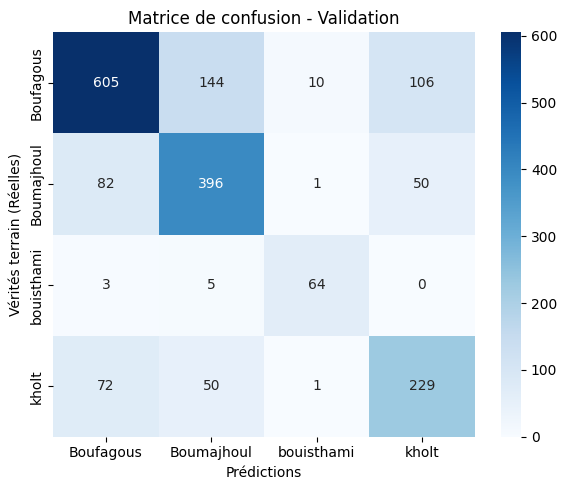

In [54]:


def plot_confusion_matrix(y_true, y_pred, class_names, title="Matrice de confusion"):
    """
    Affiche une matrice de confusion avec seaborn
    """

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Prédictions")
    plt.ylabel("Vérités terrain (Réelles)")
    plt.title(title)

    plt.tight_layout()
    plt.show()
    
    
plot_confusion_matrix(
    y_true,
    y_pred,
    val_dataset.classes,
    "Matrice de confusion - Validation"
)

* Sauvegarder le modèle entraîné

In [56]:


def save_model(model, optimizer, history, save_dir, model_name):
    """
    Sauvegarder un modèle PyTorch avec optimizer et historique

    Args:
        model : modèle PyTorch
        optimizer : optimizer utilisé pour l'entraînement
        history : dictionnaire contenant loss/accuracy
        save_dir : dossier de sauvegarde
        model_name : nom du fichier modèle
    """

    os.makedirs(save_dir, exist_ok=True)

    save_path = os.path.join(save_dir, model_name)

    torch.save({
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "history": history
    }, save_path)

    print(f"✅ Modèle sauvegardé : {save_path}")
    
    
save_model(
    model,
    optimiseur,
    history,
    "../models",
    "model_classes_variete_googlenet_model.pth"
)

✅ Modèle sauvegardé : ../models\model_classes_variete_googlenet_model.pth
